### Notbeook for testing the Divergence of a field

In [81]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import xarray as xr 
from functions.funcs import *

In [101]:
ds = xr.open_dataset('Data/krigging_field.nc')
target_date = pd.to_datetime("2024-6-12", format="%Y-%m-%d")
slice_t = ds.sel(time =target_date)

In [118]:
import numpy as np

def divergence(u, v, dx, dy, field = False):
    du_dx = np.gradient(u, dx, axis=1)
    dv_dy = np.gradient(v, dy, axis=0)
    if field == True: 
        return du_dx + dv_dy
    return np.abs((du_dx + dv_dy)).mean()

def vorticity(u,v,dx, dy, field = False): 
    dv_dx = np.gradient(v,dx, axis =1 )
    du_dy = np.gradient(u,dy, axis =1)
    if field == True: 
        return dv_dx - du_dy
    return np.abs((dv_dx - du_dy)).mean()


def helmholtz_div_free(u, v, dx, dy):
    from scipy.fft import fft2, ifft2, fftfreq
    # 1. Compute vorticity
    dv_dx = np.gradient(v, dx, axis=1)
    du_dy = np.gradient(u, dy, axis=0)
    omega = dv_dx - du_dy

    # 2. Solve Poisson equation ∇²ψ = -ω using FFT
    ny, nx = u.shape
    kx = 2 * np.pi * fftfreq(nx, dx)
    ky = 2 * np.pi * fftfreq(ny, dy)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2
    K2[0,0] = 1  # avoid divide-by-zero for mean

    psi_hat = fft2(-omega) / K2
    psi_hat[0,0] = 0     # enforce zero-mean streamfunction
    psi = np.real(ifft2(psi_hat))

    # 3. Divergence-free velocities
    u_s = np.gradient(psi, dy, axis=0)        # dψ/dy
    v_s = -np.gradient(psi, dx, axis=1)       # -dψ/dx

    return u_s, v_s, psi

2.051123196202181e-06 1.6696178845241382e-06


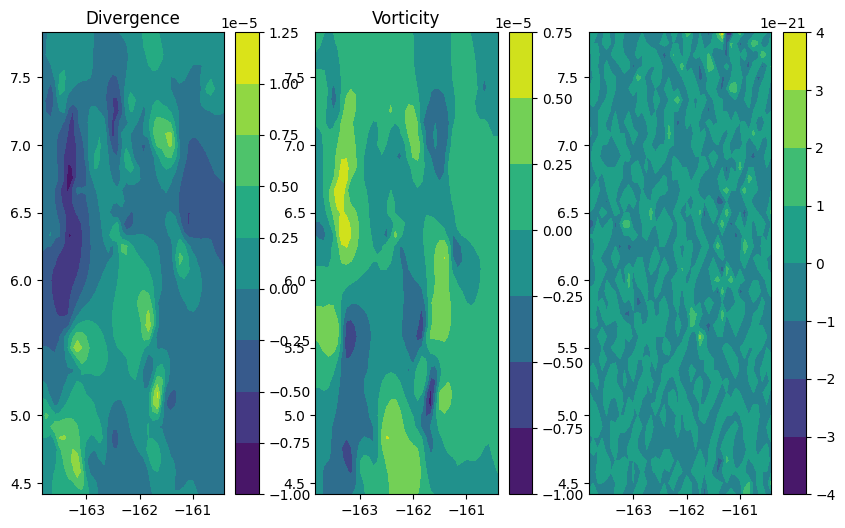

In [122]:
target_date = pd.to_datetime("2025-6-13", format="%Y-%m-%d")
slice_t = ds.sel(time =target_date)

dx = haversine_dist(6.1, 163, 6.1, 163 +1/12) *1000

div = divergence(slice_t.uo, slice_t.vo, dx,dx, field = True)
vor = vorticity(slice_t.uo, slice_t.vo, dx,dx, field = True)
divv = divergence(slice_t.uo, slice_t.vo, dx,dx)
vorv = vorticity(slice_t.uo, slice_t.vo, dx,dx)
u_df, v_df, psi = helmholtz_div_free(slice_t.uo, slice_t.vo, dx,dx)
div_df = divergence(u_df, v_df, dx, dx, field = True)

X, Y = np.meshgrid(slice_t.lon.to_numpy(), slice_t.lat.to_numpy())
fig, ax = plt.subplots(1,3, figsize = (10,6))
c1 = ax[0].contourf(X,Y, div)
c2 = ax[1].contourf(X,Y, vor)
c3 = ax[2].contourf(X,Y, div_df)
fig.colorbar(c1, ax=ax[0])
fig.colorbar(c2, ax=ax[1])
fig.colorbar(c3, ax=ax[2])

ax[0].set_title("Divergence")
ax[1].set_title("Vorticity")
print(divv,vorv)

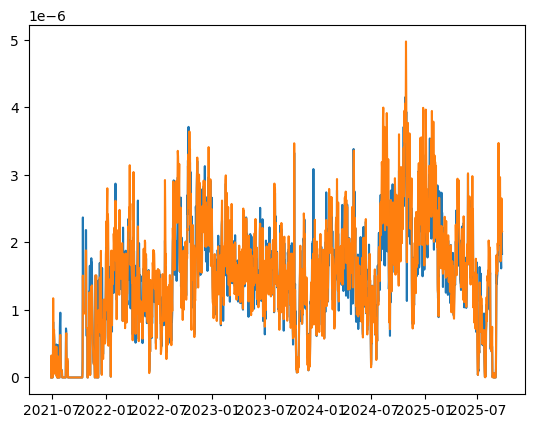

In [109]:
dx = haversine_dist(6.1, 163, 6.1, 163 +1/12) *1000

divergences = []
vorticities = []

for each in ds.time: 
    slice_t  = ds.sel(time =each)
    divergences.append(divergence(slice_t.uo, slice_t.vo, dx,dx))
    vorticities.append(vorticity(slice_t.uo, slice_t.vo, dx,dx))

fig, ax = plt.subplots()
ax.plot(ds.time, np.abs(divergences), label = "divergence")
ax.plot(ds.time, np.abs(vorticities), label = "vorticity")


In [115]:
x = np.array(([1,2,3,4], [5,6,7,8,]))
x.ravel("c")

array([1, 2, 3, 4, 5, 6, 7, 8])